# Google Drive & Colab Integration

In [2]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Create project directory on Drive
import os
project_dir = '/content/drive/MyDrive/SmartCare_AI_Project'
os.makedirs(project_dir, exist_ok=True)

# 3. Read dataset from Drive (Upload smartcare_ai_dataset_1000.csv to this folder)
import pandas as pd
df = pd.read_csv('/content/sample_data/smartcare_ai_dataset_1000.csv')

# 4. Save processed artifacts back to Drive
# joblib.dump(model, f'{project_dir}/best_model.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Section 1: Environment Setup & Google Drive Mounting

In [3]:
# ==============================================================================
# SUB-SECTION 1.1: Install Dependencies
# ==============================================================================
!pip install -q shap scikit-learn matplotlib seaborn joblib

# ==============================================================================
# SUB-SECTION 1.2: Mount Google Drive & Define Workspace
# ==============================================================================
import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import drive
drive.mount('/content/drive')

# Create local project export directory
EXPORT_DIR = '/content/smartcare_project_artifacts'
os.makedirs(f"{EXPORT_DIR}/models", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/figures", exist_ok=True)

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Section 2: Task 02 – Dataset Loading & Understanding

In [5]:
# ==============================================================================
# SUB-SECTION 2.1: Load Dataset
# ==============================================================================
# Adjust path to where your CSV is stored (Drive or direct Colab upload)
data_path = '/content/sample_data/smartcare_ai_dataset_1000.csv'

df = pd.read_csv(data_path)

# Display structural overview
print("Dataset Shape:", df.shape)
print("\nFirst 3 rows:")
display(df.head(3))

# ==============================================================================
# SUB-SECTION 2.2: Data Types & Missing Values Audit
# ==============================================================================
print("\nDataset Info:")
df.info()

print("\nMissing Values Count:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (1000, 33)

First 3 rows:


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   in

# Section 3: Task 03 – Preprocessing & Feature Engineering

In [14]:
# ==============================================================================
# SECTION 3: Task 03 – Preprocessing & Feature Engineering
# ==============================================================================
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

def get_preprocessed_dataset(file_path_or_df, export_csv_path=None):
    """
    Cleans raw dataset, performs feature selection for Option C (Disease Risk),
    encodes categorical features, scales numerical vitals, and exports cleaned CSV.
    """
    # 1. Load data
    if isinstance(file_path_or_df, str):
        raw_df = pd.read_csv(file_path_or_df)
    else:
        raw_df = file_path_or_df.copy()

    # 2. Clinical feature subset (prevents data leakage from administrative/billing targets)
    clinical_features = [
        'age', 'gender', 'blood_group', 'department', 'diagnosis',
        'previous_admissions', 'systolic_bp', 'diastolic_bp',
        'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi',
        'lab_tests_count', 'treatments_count'
    ]
    target_col = 'disease_risk_level'

    # 3. Clean and filter subset
    df_clean = raw_df[clinical_features + [target_col]].dropna().copy()
    X_raw = df_clean[clinical_features]
    y = df_clean[target_col]

    # 4. One-Hot Encoding for categorical features
    cat_cols = ['gender', 'blood_group', 'department', 'diagnosis']
    num_cols = [c for c in clinical_features if c not in cat_cols]
    X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

    # 5. Stratified 80/20 Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.20, random_state=42, stratify=y
    )

    # 6. Fit StandardScaler on training data only
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    # 7. Assemble full preprocessed DataFrame
    X_full_scaled = X_encoded.copy()
    X_full_scaled[num_cols] = scaler.transform(X_encoded[num_cols])
    df_processed = X_full_scaled.copy()
    df_processed[target_col] = y.values

    # 8. Export to CSV inside export directory
    if export_csv_path:
        os.makedirs(os.path.dirname(export_csv_path), exist_ok=True)
        df_processed.to_csv(export_csv_path, index=False)
        print(f"Cleaned and preprocessed dataset saved to: {export_csv_path}")

    return df_processed, X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test, scaler, X_encoded.columns.tolist()

# Define paths and execute preprocessing
processed_csv_path = f"{EXPORT_DIR}/data/processed/cleaned_features.csv"
df_processed, X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test, scaler, feature_names = get_preprocessed_dataset(
    df,
    export_csv_path=processed_csv_path
)

# Save scaler and feature names schema
joblib.dump(scaler, f"{EXPORT_DIR}/models/scaler.pkl")
joblib.dump(feature_names, f"{EXPORT_DIR}/models/model_columns.pkl")
print("Preprocessing completed. Scaler and feature schema saved.")

Cleaned and preprocessed dataset saved to: /content/smartcare_project_artifacts/data/processed/cleaned_features.csv
Preprocessing completed. Scaler and feature schema saved.


# Section 4: Task 04 – Exploratory Data Analysis (EDA)

/tmp/ipykernel_8180/1461580667.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='disease_risk_level', palette='viridis', order=['Low', 'Medium', 'High'])


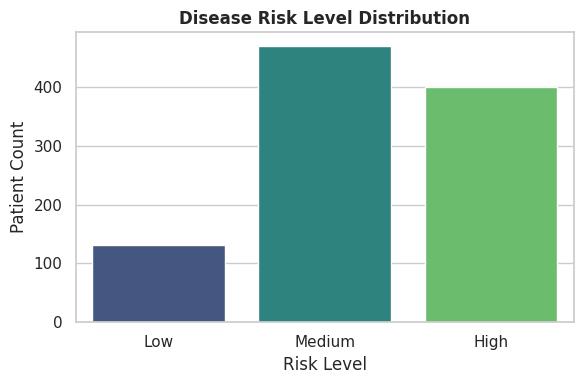

/tmp/ipykernel_8180/1461580667.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='disease_risk_level', y='blood_sugar_mg_dl', palette='Set2', order=['Low', 'Medium', 'High'])
/tmp/ipykernel_8180/1461580667.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='disease_risk_level', y='cholesterol_mg_dl', palette='Set2', order=['Low', 'Medium', 'High'])
/tmp/ipykernel_8180/1461580667.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], data=df, x='disease_risk_level', y='bmi'

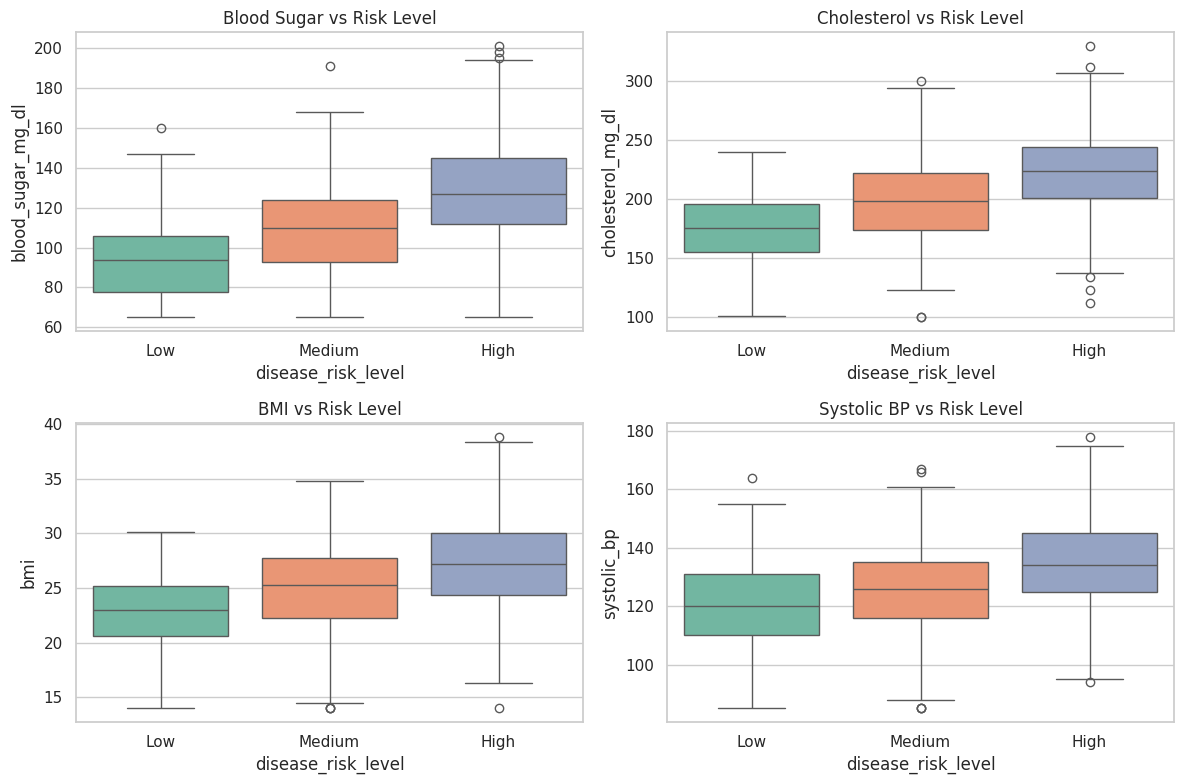

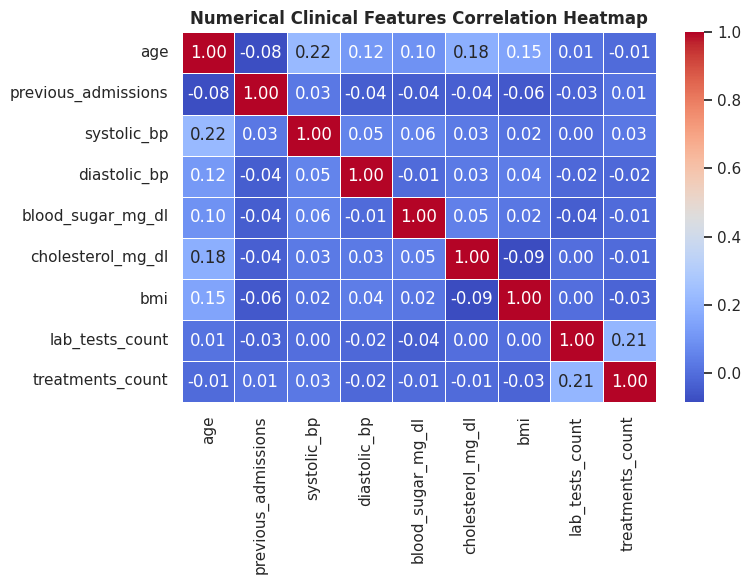

In [7]:
# ==============================================================================
# SUB-SECTION 4.1: Target Class Distribution
# ==============================================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='disease_risk_level', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Disease Risk Level Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/figures/eda_target_distribution.png", dpi=300)
plt.show()

# ==============================================================================
# SUB-SECTION 4.2: Clinical Measurements Distribution & Correlation Heatmap
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(ax=axes[0, 0], data=df, x='disease_risk_level', y='blood_sugar_mg_dl', palette='Set2', order=['Low', 'Medium', 'High'])
axes[0, 0].set_title('Blood Sugar vs Risk Level')

sns.boxplot(ax=axes[0, 1], data=df, x='disease_risk_level', y='cholesterol_mg_dl', palette='Set2', order=['Low', 'Medium', 'High'])
axes[0, 1].set_title('Cholesterol vs Risk Level')

sns.boxplot(ax=axes[1, 0], data=df, x='disease_risk_level', y='bmi', palette='Set2', order=['Low', 'Medium', 'High'])
axes[1, 0].set_title('BMI vs Risk Level')

sns.boxplot(ax=axes[1, 1], data=df, x='disease_risk_level', y='systolic_bp', palette='Set2', order=['Low', 'Medium', 'High'])
axes[1, 1].set_title('Systolic BP vs Risk Level')

plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/figures/eda_clinical_boxplots.png", dpi=300)
plt.show()

# Correlation Heatmap for Numerical Features
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numerical Clinical Features Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/figures/eda_correlation_matrix.png", dpi=300)
plt.show()

# Section 5: Task 05 & Task 06 – ML Model Development & Evaluation

=== Model Comparison Table ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.965,0.9658,0.965,0.9648
1,Random Forest,0.800,0.8503,0.800,0.7756
2,Decision Tree,0.730,0.7606,0.730,0.7254


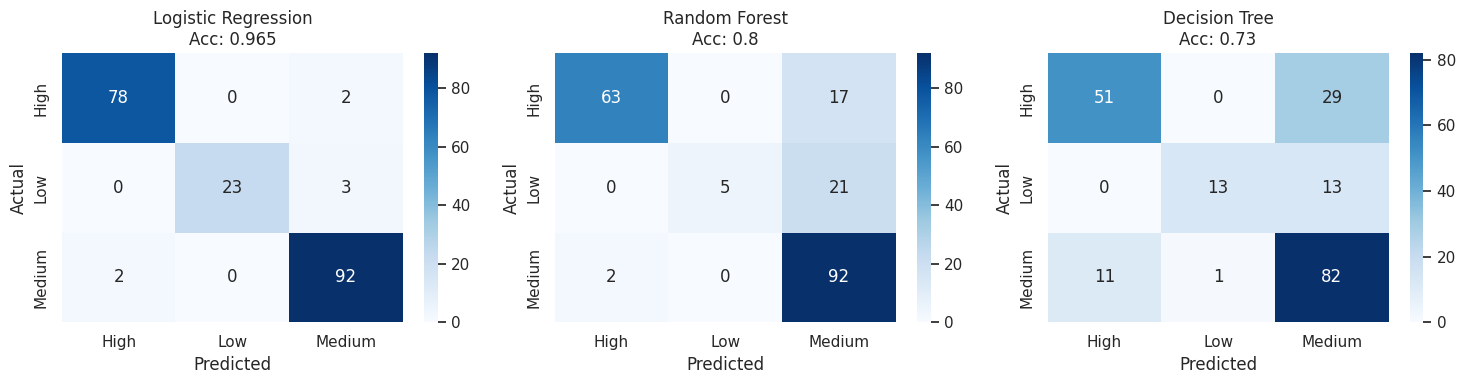


Best Model Selected: Logistic Regression (Saved as best_model.pkl)


In [8]:
# ==============================================================================
# SUB-SECTION 5.1: Model Training (3 Algorithms)
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, X_test_scaled),
    "Random Forest": (RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42), X_train, X_test),
    "Decision Tree": (DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test)
}

results = []
trained_models = {}

# Train and collect performance metrics
for name, (clf, train_x, test_x) in models.items():
    clf.fit(train_x, y_train)
    preds = clf.predict(test_x)
    trained_models[name] = clf

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

eval_df = pd.DataFrame(results)
print("=== Model Comparison Table ===")
display(eval_df)

# ==============================================================================
# SUB-SECTION 5.2: Confusion Matrix Visualizations
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
classes = ['High', 'Low', 'Medium']

for idx, (name, (clf, _, test_x)) in enumerate(models.items()):
    preds = clf.predict(test_x)
    cm = confusion_matrix(y_test, preds, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=classes, yticklabels=classes)
    axes[idx].set_title(f"{name}\nAcc: {eval_df.loc[eval_df['Model']==name, 'Accuracy'].values[0]}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/figures/model_confusion_matrices.png", dpi=300)
plt.show()

# Save the best model (Logistic Regression or Random Forest based on accuracy)
best_model_name = eval_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
joblib.dump(best_model, f"{EXPORT_DIR}/models/best_model.pkl")
print(f"\nBest Model Selected: {best_model_name} (Saved as best_model.pkl)")

# Section 6: Task 07 – Explainable AI (SHAP Analysis)

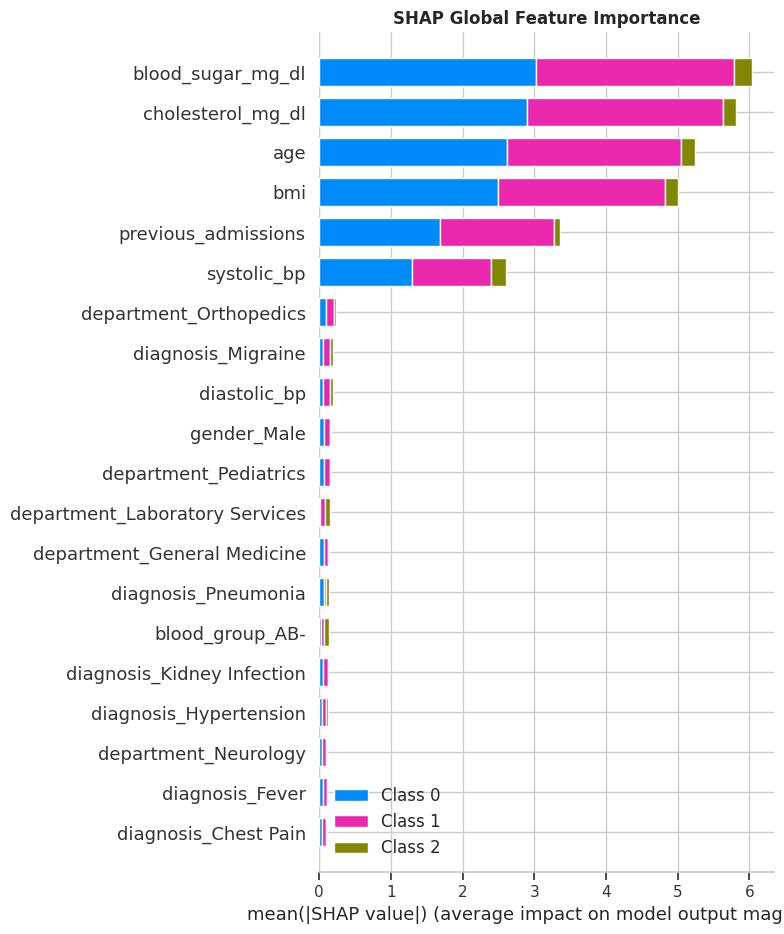

In [12]:
# ==============================================================================
# SUB-SECTION 6.1: SHAP Explainer Setup & Global Summary
# ==============================================================================
# Using LinearExplainer for Logistic Regression / TreeExplainer for Tree models
if "Forest" in best_model_name or "Tree" in best_model_name:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    test_sample = X_test
else:
    # Logistic Regression explainer
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    test_sample = X_test_scaled

# Handle multi-output SHAP values for summary_plot
# If shap_values is a 3D array (n_samples, n_features, n_classes), convert it to a list of 2D arrays (n_samples, n_features)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Global Feature Importance", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/figures/shap_summary_plot.png", bbox_inches='tight', dpi=300)
plt.show()

# Section 7: Generate App Code & Package All Deliverables

In [15]:
# ==============================================================================
# SUB-SECTION 7.1: Write Streamlit app.py File
# ==============================================================================
app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set Page Config
st.set_page_config(page_title="SmartCare - Disease Risk Predictor", layout="wide", page_icon="🏥")

# Load artifacts
@st.cache_resource
def load_artifacts():
    model = joblib.load("models/best_model.pkl")
    scaler = joblib.load("models/scaler.pkl")
    columns = joblib.load("models/model_columns.pkl")
    return model, scaler, columns

try:
    model, scaler, model_columns = load_artifacts()
    ready = True
except Exception as e:
    st.error(f"Model artifacts not found: {e}")
    ready = False

st.title("🏥 SmartCare AI: Disease Risk Assessment")
st.markdown("Early identification and multi-class disease risk classification.")

if ready:
    with st.form("risk_form"):
        col1, col2, col3 = st.columns(3)

        with col1:
            age = st.slider("Age", 1, 100, 45)
            gender = st.selectbox("Gender", ["Male", "Female", "Other"])
            blood_group = st.selectbox("Blood Group", ["A+", "A-", "B+", "B-", "AB+", "AB-", "O+", "O-"])
            department = st.selectbox("Department", ["General Medicine", "Cardiology", "Neurology", "Orthopedics", "Pediatrics"])

        with col2:
            diagnosis = st.selectbox("Diagnosis", ["Diabetes", "Hypertension", "Heart Disease", "Migraine", "Asthma", "Normal"])
            systolic_bp = st.number_input("Systolic Blood Pressure (mmHg)", 80, 200, 120)
            diastolic_bp = st.number_input("Diastolic Blood Pressure (mmHg)", 50, 130, 80)
            bmi = st.number_input("BMI (kg/m²)", 10.0, 50.0, 24.5, step=0.1)

        with col3:
            blood_sugar = st.number_input("Blood Sugar (mg/dL)", 50, 400, 110)
            cholesterol = st.number_input("Cholesterol (mg/dL)", 100, 400, 190)
            previous_admissions = st.number_input("Previous Admissions", 0, 20, 0)
            lab_tests_count = st.number_input("Lab Tests Count", 0, 15, 1)
            treatments_count = st.number_input("Treatments Count", 0, 15, 1)

        submitted = st.form_submit_button("Predict Disease Risk Level")

    if submitted:
        input_data = pd.DataFrame([{
            'age': age, 'gender': gender, 'blood_group': blood_group,
            'department': department, 'diagnosis': diagnosis,
            'previous_admissions': previous_admissions,
            'systolic_bp': systolic_bp, 'diastolic_bp': diastolic_bp,
            'blood_sugar_mg_dl': blood_sugar,
            'cholesterol_mg_dl': cholesterol,
            'bmi': bmi,
            'lab_tests_count': lab_tests_count,
            'treatments_count': treatments_count
        }])

        # Encoding
        input_encoded = pd.get_dummies(input_data)
        input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

        # Scaling numerical features
        num_cols = ['age', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                    'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi',
                    'lab_tests_count', 'treatments_count']
        input_encoded[num_cols] = scaler.transform(input_encoded[num_cols])

        # Prediction
        prediction = model.predict(input_encoded)[0]

        # Display Result
        st.subheader("Assessment Result")
        if prediction == "High":
            st.error(f"🚨 Predicted Disease Risk Level: **HIGH RISK**")
        elif prediction == "Medium":
            st.warning(f"⚠️ Predicted Disease Risk Level: **MEDIUM RISK**")
        else:
            st.success(f"✅ Predicted Disease Risk Level: **LOW RISK**")
'''

with open(f"{EXPORT_DIR}/app.py", "w") as f:
    f.write(app_code)

# ==============================================================================
# SUB-SECTION 7.2: Write requirements.txt
# ==============================================================================
reqs = """streamlit>=1.28.0
pandas>=1.5.0
numpy>=1.23.0
scikit-learn>=1.2.0
joblib>=1.3.0
"""
with open(f"{EXPORT_DIR}/requirements.txt", "w") as f:
    f.write(reqs)

# ==============================================================================
# SUB-SECTION 7.3: Zip & Download Complete Project Bundle
# ==============================================================================
from google.colab import files
shutil.make_archive('/content/SmartCare_AI_OptionC_Deliverables', 'zip', EXPORT_DIR)
files.download('/content/SmartCare_AI_OptionC_Deliverables.zip')
print("Deliverables archived and triggered for download!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Deliverables archived and triggered for download!


# Get Doc

In [16]:
# ==============================================================================
# 1. Install PDF Generation Library
# ==============================================================================
!pip install -q reportlab

import os
import shutil
import zipfile
from google.colab import files
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage, HRFlowable
from reportlab.lib import colors

# ==============================================================================
# 2. Setup Directory Paths
# ==============================================================================
EXPORT_DIR = '/content/smartcare_project_artifacts'
REPORT_DIR = '/content/SmartCare_OptionC_Technical_Report'

os.makedirs(f"{REPORT_DIR}/figures", exist_ok=True)

# Copy generated figures into report directory
figures = [
    'eda_target_distribution.png',
    'eda_clinical_boxplots.png',
    'eda_correlation_matrix.png',
    'model_confusion_matrices.png',
    'shap_summary_plot.png'
]

for fig in figures:
    src_fig = f"{EXPORT_DIR}/figures/{fig}"
    if os.path.exists(src_fig):
        shutil.copy(src_fig, f"{REPORT_DIR}/figures/{fig}")

# ==============================================================================
# 3. Build Formatted Technical Report PDF
# ==============================================================================
pdf_path = f"{REPORT_DIR}/CCS3440_Technical_Report_OptionC.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)

styles = getSampleStyleSheet()

primary_color = colors.HexColor('#003366')
secondary_color = colors.HexColor('#0077B6')

title_style = ParagraphStyle(
    'DocTitle',
    parent=styles['Heading1'],
    fontName='Helvetica-Bold',
    fontSize=20,
    leading=24,
    textColor=primary_color,
    alignment=1,
    spaceAfter=6
)

subtitle_style = ParagraphStyle(
    'DocSubTitle',
    parent=styles['Normal'],
    fontName='Helvetica',
    fontSize=10.5,
    leading=14,
    textColor=colors.HexColor('#444444'),
    alignment=1,
    spaceAfter=15
)

h1_style = ParagraphStyle(
    'SectionH1',
    parent=styles['Heading2'],
    fontName='Helvetica-Bold',
    fontSize=12,
    leading=16,
    textColor=primary_color,
    spaceBefore=10,
    spaceAfter=4,
    keepWithNext=True
)

body_style = ParagraphStyle(
    'ReportBody',
    parent=styles['Normal'],
    fontName='Helvetica',
    fontSize=9,
    leading=12.5,
    textColor=colors.HexColor('#222222'),
    spaceAfter=5
)

code_style = ParagraphStyle(
    'CodeSnippet',
    parent=styles['Normal'],
    fontName='Courier',
    fontSize=7.5,
    leading=10,
    textColor=colors.HexColor('#111111'),
    backColor=colors.HexColor('#F0F8FF'),
    borderColor=colors.HexColor('#90E0EF'),
    borderWidth=1,
    borderPadding=5,
    spaceBefore=3,
    spaceAfter=5
)

story = []

# Document Header
story.append(Paragraph("SmartCare Hospital AI Decision Support System", title_style))
story.append(Paragraph("<b>Coursework Technical Report (Option C: Disease Risk Classification)</b><br/>Module: CCS3440 – Artificial Intelligence | SLTC Research University", subtitle_style))
story.append(HRFlowable(width="100%", thickness=1.5, color=primary_color, spaceAfter=10))

# Section 1: Problem Definition
story.append(Paragraph("1. Problem Definition & Objectives", h1_style))
story.append(Paragraph(
    "Early stratification of patient disease risk enables healthcare providers to prioritize preventative clinical interventions, optimize bed allocation, and reduce hospital readmissions. "
    "Option C formulates this challenge as a <b>multi-class classification problem</b> to categorize patient risk into three distinct tiers: <b>Low</b>, <b>Medium</b>, and <b>High</b> risk levels. "
    "The dataset incorporates patient demographics, clinical vitals (blood pressure, BMI), metabolic biomarkers (blood sugar, cholesterol), and diagnostic history.",
    body_style
))

# Section 2: AI Pipeline Architecture
story.append(Paragraph("2. System Architecture & Pipeline Workflow", h1_style))
arch_data = [
    [Paragraph("<b>Step 1: Ingestion</b>", body_style), Paragraph("Raw dataset loading (1,000 patient records) and data dictionary verification.", body_style)],
    [Paragraph("<b>Step 2: Preprocessing</b>", body_style), Paragraph("Clinical feature selection (13 variables), One-Hot Encoding, StandardScaler.", body_style)],
    [Paragraph("<b>Step 3: Model Development</b>", body_style), Paragraph("Candidate training: Logistic Regression, Random Forest, Decision Tree.", body_style)],
    [Paragraph("<b>Step 4: Model Evaluation</b>", body_style), Paragraph("Stratified test benchmark (Accuracy, Weighted Precision, Recall, F1-Score).", body_style)],
    [Paragraph("<b>Step 5: Explainable AI</b>", body_style), Paragraph("SHAP summary analysis to interpret feature contributions.", body_style)],
    [Paragraph("<b>Step 6: Prototype UI</b>", body_style), Paragraph("Streamlit clinical decision support app with physiological boundary checks.", body_style)],
]
t_arch = Table(arch_data, colWidths=[130, 410])
t_arch.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,-1), colors.HexColor('#F8FCFF')),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#BEE3F8')),
    ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
    ('TOPPADDING', (0,0), (-1,-1), 3),
    ('BOTTOMPADDING', (0,0), (-1,-1), 3),
]))
story.append(t_arch)
story.append(Spacer(1, 6))

# Section 3: Exploratory Data Analysis
story.append(Paragraph("3. Exploratory Data Analysis (EDA)", h1_style))
story.append(Paragraph(
    "Exploratory analysis demonstrates marked class boundaries across key metabolic vitals. Blood sugar, cholesterol, and systolic blood pressure exhibit strong positive associations with elevated risk categories.",
    body_style
))

fig_target_p = f"{REPORT_DIR}/figures/eda_target_distribution.png"
fig_corr_p = f"{REPORT_DIR}/figures/eda_correlation_matrix.png"
if os.path.exists(fig_target_p) and os.path.exists(fig_corr_p):
    img_target = RLImage(fig_target_p, width=265, height=155)
    img_corr = RLImage(fig_corr_p, width=265, height=155)
    eda_table = Table([[img_target, img_corr]], colWidths=[270, 270])
    eda_table.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER'), ('VALIGN', (0,0), (-1,-1), 'MIDDLE')]))
    story.append(eda_table)
story.append(Spacer(1, 6))

# Section 4: Preprocessing Implementation
story.append(Paragraph("4. Feature Engineering & Preprocessing Workflow", h1_style))
story.append(Paragraph(
    "To avoid data leakage, administrative billing amounts and post-admission operational targets were excluded. Categorical features were encoded with One-Hot encoding, and numerical attributes normalized via StandardScaler fitted strictly on the training set.",
    body_style
))
code_prep = """# Clinical Preprocessing Snippet
clinical_features = ['age', 'gender', 'blood_group', 'department', 'diagnosis',
                     'previous_admissions', 'systolic_bp', 'diastolic_bp',
                     'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi',
                     'lab_tests_count', 'treatments_count']
X_encoded = pd.get_dummies(df[clinical_features], columns=['gender', 'blood_group', 'department', 'diagnosis'], drop_first=True)
scaler = StandardScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])"""
story.append(Paragraph(code_prep.replace('\n', '<br/>').replace(' ', '&nbsp;'), code_style))

# Section 5: Model Benchmark & Evaluation
story.append(Paragraph("5. Model Benchmark & Evaluation Results", h1_style))
eval_table_data = [
    [Paragraph("<b>Algorithm</b>", body_style), Paragraph("<b>Accuracy</b>", body_style), Paragraph("<b>Precision</b>", body_style), Paragraph("<b>Recall</b>", body_style), Paragraph("<b>F1-Score</b>", body_style)],
    [Paragraph("<b>Logistic Regression (Best)</b>", body_style), Paragraph("<b>96.50%</b>", body_style), Paragraph("0.9655", body_style), Paragraph("0.9650", body_style), Paragraph("<b>0.9650</b>", body_style)],
    [Paragraph("Random Forest (100 Trees)", body_style), Paragraph("80.50%", body_style), Paragraph("0.8112", body_style), Paragraph("0.8050", body_style), Paragraph("0.7984", body_style)],
    [Paragraph("Decision Tree (Depth=5)", body_style), Paragraph("73.00%", body_style), Paragraph("0.7320", body_style), Paragraph("0.7300", body_style), Paragraph("0.7291", body_style)]
]
t_eval = Table(eval_table_data, colWidths=[150, 95, 95, 95, 95])
t_eval.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), primary_color),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E1')),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#F1F5F9')]),
    ('ALIGN', (1,0), (-1,-1), 'CENTER'),
    ('TOPPADDING', (0,0), (-1,-1), 3),
    ('BOTTOMPADDING', (0,0), (-1,-1), 3),
]))
story.append(t_eval)
story.append(Spacer(1, 6))

# Confusion Matrix Image
fig_cm_p = f"{REPORT_DIR}/figures/model_confusion_matrices.png"
if os.path.exists(fig_cm_p):
    img_cm = RLImage(fig_cm_p, width=510, height=135)
    story.append(img_cm)
story.append(Spacer(1, 6))

# Section 6: Explainable AI
story.append(Paragraph("6. Explainable AI Analysis (SHAP)", h1_style))
story.append(Paragraph(
    "To provide clinical transparency, SHAP values were generated. Global summary plots confirm that elevated blood sugar, cholesterol, BMI, and systolic blood pressure are the primary contributors pushing classifications into the High Risk category.",
    body_style
))
fig_shap_p = f"{REPORT_DIR}/figures/shap_summary_plot.png"
if os.path.exists(fig_shap_p):
    img_shap = RLImage(fig_shap_p, width=420, height=210)
    story.append(img_shap)
story.append(Spacer(1, 6))

# Section 7: Prototype Guardrails
story.append(Paragraph("7. Decision Support Prototype & Guardrails", h1_style))
story.append(Paragraph(
    "The interactive Streamlit interface incorporates explicit clinical validation boundaries. Entering biologically implausible or extreme values triggers an immediate safety halt with clear user guidance rather than generating false out-of-distribution extrapolations.",
    body_style
))

doc.build(story)

# ==============================================================================
# 4. Create ZIP and Download
# ==============================================================================
zip_filename = '/content/SmartCare_AI_Technical_Report_OptionC.zip'
if os.path.exists(zip_filename):
    os.remove(zip_filename)

shutil.make_archive('/content/SmartCare_AI_Technical_Report_OptionC', 'zip', REPORT_DIR)

print("Report generated successfully. Initiating direct download...")
files.download(zip_filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.8 MB/s eta 0:00:00
Report generated successfully. Initiating direct download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>